# DRAGON QUEST VII Reimagined 中古価格分析（PS5 / Switch / Switch2）

Mercari（メルカリ）日本市場の中古ソフト出品データをもとに、**ドラゴンクエストVII リメイク（Reimagined, 「DQ7R」）**
の中古価格を探索的に分析するノートです。

- 対象 `game_id`: `dq7r_reimagined_ps5`, `dq7r_reimagined_switch`, `dq7r_reimagined_switch2`
- データ元: `market_listings_clean`（パイプラインで生成済みのクリーン済みテーブル）
- このノートは **読み取り専用** です。スクレイピング・パイプライン実行・スキーマ変更は一切行いません。

> 本文中の数値・表・図はすべて **実行時に DB から計算** しています（過去のスナップショットをハードコードしていません）。

In [1]:
import sqlite3
import warnings
import textwrap
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

# macOS / Linux に入っている日本語フォントを使い、ラベルが豆腐（□）にならないようにする。
# 無ければそのまま（描画自体は崩れない）。
for _f in ["Hiragino Sans", "Hiragino Maru Gothic Pro", "YuGothic",
           "Noto Sans CJK JP", "IPAexGothic"]:
    if any(_f == f.name for f in matplotlib.font_manager.fontManager.ttflist):
        plt.rcParams["font.family"] = _f
        break
plt.rcParams["axes.unicode_minus"] = False

## 2. データ読み込み & 品質確認

`market_listings_clean` から DQ7R の 3 つの `game_id` を読み込み、行数・状態・コンディション・価格レンジを
確認します。あわせて `platform_final`（詳細データから推定し直したプラットフォーム）の混入状況を見ます。

In [2]:
# notebooks/ からでもリポジトリ直下からでも DB を見つけられるように。
def find_db() -> Path:
    for base in (Path.cwd(), Path.cwd().parent):
        p = base / "data" / "mercari.sqlite"
        if p.exists():
            return p
    raise FileNotFoundError(
        "data/mercari.sqlite が見つかりません — 先に scrape / clean ステップを実行してください。"
    )

GAME_IDS = ["dq7r_reimagined_ps5", "dq7r_reimagined_switch", "dq7r_reimagined_switch2"]
# 表示用：game_id 由来のバケット区分（＝データセットの取り込み単位）
BUCKET = {
    "dq7r_reimagined_ps5": "PS5",
    "dq7r_reimagined_switch": "Switch (game_id)",
    "dq7r_reimagined_switch2": "Switch2 (game_id)",
}

conn = sqlite3.connect(find_db())
df_all = pd.read_sql_query(
    f"""
    SELECT game_id, listing_id, price_jpy, status_final, condition_raw,
           platform_final, title_raw, scraped_at, created_at, days_since_release
    FROM market_listings_clean
    WHERE game_id IN ({','.join('?' * len(GAME_IDS))})
    """,
    conn, params=GAME_IDS,
)
conn.close()

df_all["platform_bucket"] = df_all["game_id"].map(BUCKET)
print("df_all.shape:", df_all.shape)
df_all.head()

df_all.shape: (1590, 11)


,game_id,listing_id,price_jpy,status_final,condition_raw,platform_final,title_raw,scraped_at,created_at,days_since_release,platform_bucket
0,dq7r_reimagined_ps5,m12447643977,3600.0,on_sale,目立った傷や汚れなし,PS5,DRAGON QUEST Ⅶ Reimagined PS5,2026-06-22T05:01:48.394374+00:00,2026-06-22T05:19:25.053148+00:00,None,PS5
1,dq7r_reimagined_ps5,m52485414106,5000.0,on_sale,目立った傷や汚れなし,unknown,ドラクエ7 リメイク Switch版,2026-06-22T05:01:52.721193+00:00,2026-06-22T05:19:25.053295+00:00,None,PS5
2,dq7r_reimagined_ps5,m20137354638,3500.0,on_sale,目立った傷や汚れなし,PS5,ドラゴンクエストVII リメイク PS5,2026-06-22T05:02:03.325604+00:00,2026-06-22T05:19:25.053313+00:00,None,PS5
3,dq7r_reimagined_ps5,m82968390675,4900.0,sold_out,目立った傷や汚れなし,unknown,ドラゴンクエストVII リメイク Nintendo Switch,2026-06-22T05:02:18.395934+00:00,2026-06-22T05:19:25.053330+00:00,None,PS5
4,dq7r_reimagined_ps5,m85908004232,3000.0,sold_out,未使用に近い,unknown,ドラゴンクエストVII リメイク Nintendo Switch,2026-06-22T05:02:26.892665+00:00,2026-06-22T05:19:25.053346+00:00,None,PS5


In [3]:
print("=== game_id 別 行数（全クリーン行） ===")
print(df_all["game_id"].value_counts(), "\n")

print("=== status_final 別 件数（game_id 別） ===")
print(df_all.groupby("game_id")["status_final"].value_counts(), "\n")

print("=== condition_raw 上位カテゴリ（game_id 別・上位5） ===")
for gid in GAME_IDS:
    print(f"-- {gid} --")
    print(df_all[df_all.game_id == gid]["condition_raw"].value_counts().head(5), "\n")

print("=== price_jpy の min / median / max（game_id 別・全行） ===")
print(df_all.groupby("game_id")["price_jpy"].agg(["count", "min", "median", "mean", "max"]).round(0), "\n")

print("=== platform_bucket × platform_final クロス集計（対角線以外＝混入分） ===")
print(pd.crosstab(df_all["platform_bucket"], df_all["platform_final"]))

=== game_id 別 行数（全クリーン行） ===
game_id
dq7r_reimagined_switch     604
dq7r_reimagined_ps5        538
dq7r_reimagined_switch2    448
Name: count, dtype: int64 

=== status_final 別 件数（game_id 別） ===
game_id                  status_final
dq7r_reimagined_ps5      sold_out        449
                         on_sale          88
                         trading           1
dq7r_reimagined_switch   sold_out        494
                         on_sale         109
                         trading           1
dq7r_reimagined_switch2  sold_out        357
                         on_sale          90
                         trading           1
Name: count, dtype: int64 

=== condition_raw 上位カテゴリ（game_id 別・上位5） ===
-- dq7r_reimagined_ps5 --
condition_raw
目立った傷や汚れなし    311
未使用に近い        180
新品、未使用         43
やや傷や汚れあり        3
傷や汚れあり          1
Name: count, dtype: int64 

-- dq7r_reimagined_switch --
condition_raw
目立った傷や汚れなし    329
未使用に近い        216
新品、未使用         55
やや傷や汚れあり        3
傷や汚れあり          1

### データ品質メモ：プラットフォーム混入と `platform_final`

DQ7R は PS5 / Switch / Switch2 で検索キーワードがほぼ共通のため、**プラットフォームが明記されていない出品**
（特に「Switch」とだけ書かれた Switch1 想定の出品）は複数の `game_id` に候補として取り込まれます。
クリーンテーブルの `platform_final` はタイトル・説明文から推定し直した値ですが、次の特徴があります。

- **`unknown` が最大バケット**：分類器（`guess_platform`）は PS5 / Switch 2 のトークンしか判定できず、
  素の「Switch」（Switch1）を判別できないため `unknown` に落ちます。
- **`platform_final == 'PS5'` / `'Switch 2'` で確定できる行は全体の半分弱**（残りは `unknown` と逆プラットフォームの混入）。
- **`dq7r_reimagined_switch` はプラットフォームガードが無い**（`expected_platform('Nintendo Switch')` → `None`）ため、
  PS5 / Switch / Switch2 が混在します。真の Switch1 行は `unknown` の中に埋もれており、
  **分類器を変更しない限り Switch1 単独の抽出はできません**。

**このノートの方針**：プラットフォーム別の分析・比較では、

- PS5 版 → `game_id == 'dq7r_reimagined_ps5'` の **バケットビュー（全体）** と、
  `platform_final == 'PS5'` だけに絞った **精製ビュー** の両方を見ます。
- Switch2 版 → 同様に `game_id == 'dq7r_reimagined_switch2'` のバケットビューと、
  `platform_final == 'Switch 2'` の精製ビューを見ます。

サンプル数（バケット）と確度（精製）のトレードオフを意識して読みます。

In [4]:
# 共通ヘルパ：価格ヒストグラム（500円刻み・98パーセンタイル以下を表示して外れ値で潰れないように）
def price_hist(d, title, color="steelblue"):
    hi = int(np.ceil(d["price_jpy"].quantile(0.98) / 500) * 500)
    sub = d[d["price_jpy"] <= hi]
    bins = np.arange(0, hi + 500, 500)
    fig, ax = plt.subplots(figsize=(9, 4))
    sns.histplot(sub["price_jpy"], bins=bins, color=color, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("価格（円, 500円刻み・98パーセンタイル以下を表示）")
    ax.set_ylabel("件数")
    plt.show()

# 共通ヘルパ：横向きボックスプロット
def price_box(d, title, color="steelblue"):
    fig, ax = plt.subplots(figsize=(9, 2.4))
    sns.boxplot(x=d["price_jpy"], color=color, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("価格（円）")
    plt.show()

# 共通ヘルパ：1ビュー分の3図（価格ヒスト / 箱ひげ / 成約済みヒスト）
def view_block(d, platform_label, view_name, color):
    price_hist(d, f"DQ7R {platform_label}版 価格ヒストグラム（{view_name}）", color)
    price_box(d,  f"DQ7R {platform_label}版 価格ボックスプロット（{view_name}）", color)
    price_hist(d[d.status_final == "sold_out"],
               f"DQ7R {platform_label}版 成約済み価格ヒストグラム（{view_name}）", color)

# 共通ヘルパ：要約統計（件数 / 成約率 / 中央値 / 平均 / 四分位）
def summarize(d):
    return pd.Series({
        "件数": len(d),
        "成約率": round((d["status_final"] == "sold_out").mean(), 3) if len(d) else np.nan,
        "価格中央値": d["price_jpy"].median(),
        "平均価格": round(d["price_jpy"].mean()) if len(d) else np.nan,
        "第1四分位": d["price_jpy"].quantile(0.25),
        "第3四分位": d["price_jpy"].quantile(0.75),
    })

# 4つの分析ビューを定義
ps5_bucket  = df_all[df_all.game_id == "dq7r_reimagined_ps5"].copy()
ps5_refined = df_all[(df_all.game_id == "dq7r_reimagined_ps5") & (df_all.platform_final == "PS5")].copy()
sw2_bucket  = df_all[df_all.game_id == "dq7r_reimagined_switch2"].copy()
sw2_refined = df_all[(df_all.game_id == "dq7r_reimagined_switch2") & (df_all.platform_final == "Switch 2")].copy()

print(f"PS5    バケット: {len(ps5_bucket):4d} 行 / 精製(platform_final=='PS5')     : {len(ps5_refined):4d} 行")
print(f"Switch2 バケット: {len(sw2_bucket):4d} 行 / 精製(platform_final=='Switch 2'): {len(sw2_refined):4d} 行")

PS5    バケット:  538 行 / 精製(platform_final=='PS5')     :  248 行
Switch2 バケット:  448 行 / 精製(platform_final=='Switch 2'):  206 行


## 3. PS5版の価格分布

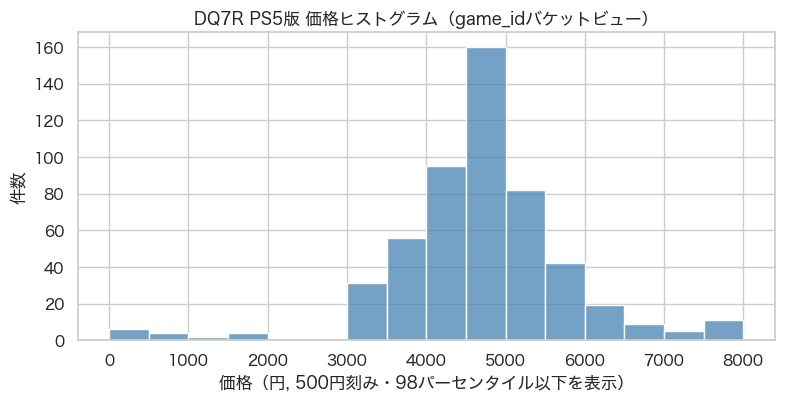

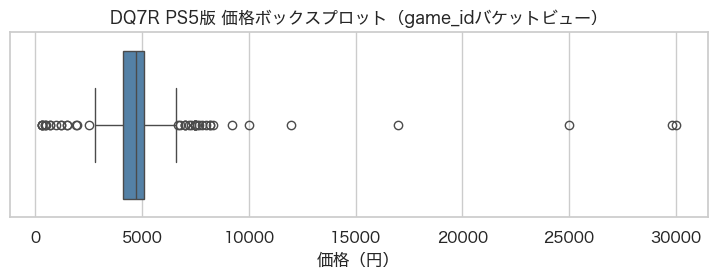

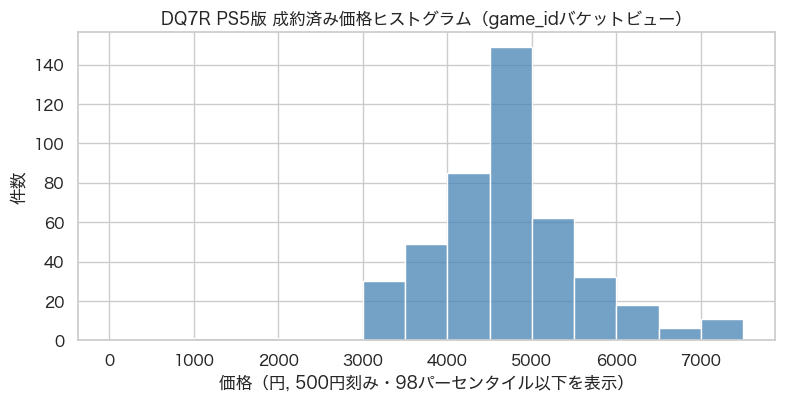

In [5]:
view_block(ps5_bucket, "PS5", "game_idバケットビュー", "steelblue")

**game_id バケットビュー（`dq7r_reimagined_ps5` 全体）**：サンプル数は最も多いものの、
プラットフォーム未記載（`unknown`）や Switch2 等の混入を含み得ます。価格の山の位置と、
極端に安い／高い案件（テール）の有無を確認します。

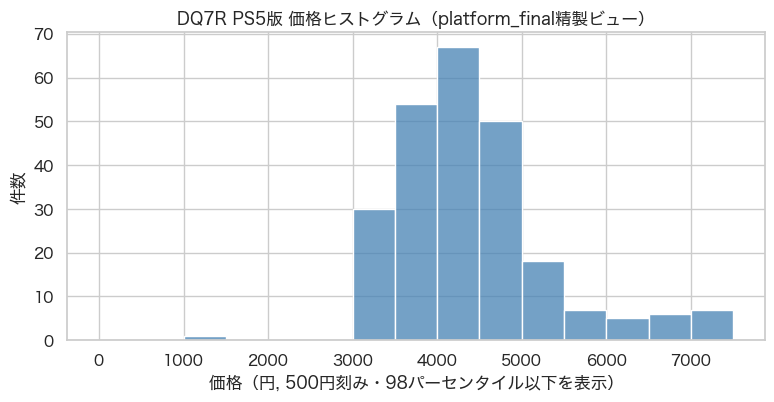

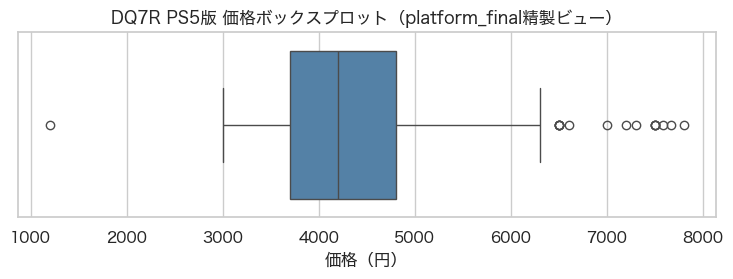

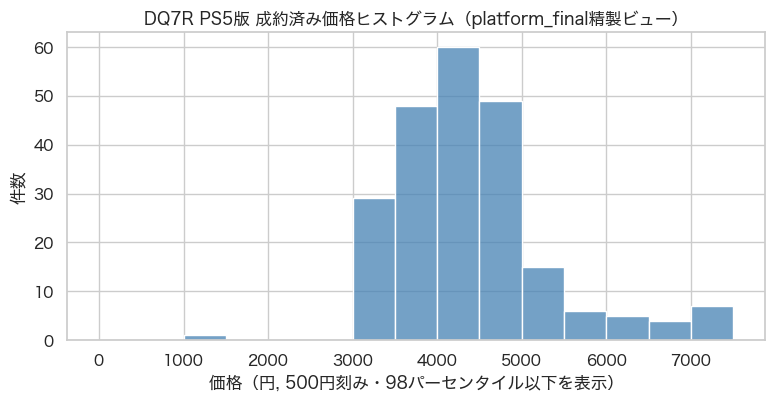

In [6]:
view_block(ps5_refined, "PS5", "platform_final精製ビュー", "steelblue")

**platform_final 精製ビュー（`platform_final == 'PS5'`）**：サンプルは減りますが、
PS5 ソフトである確度が高い行に絞られます。バケットビューと中央値付近の価格帯がどれだけ一致するか、
混入によって相場感がぶれていないかを見ます。

## 4. Switch2版の価格分布

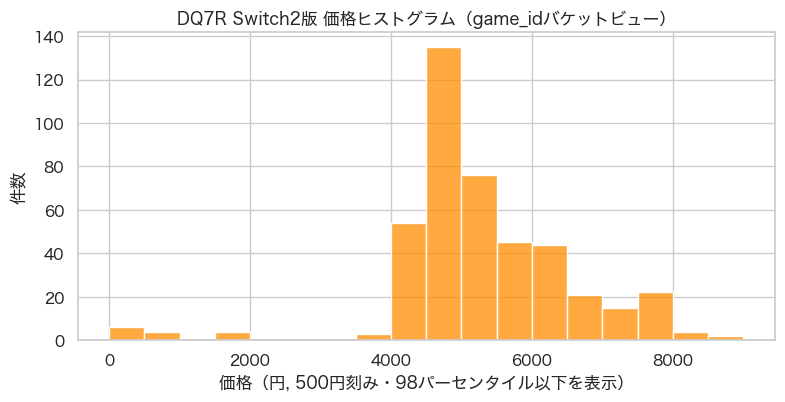

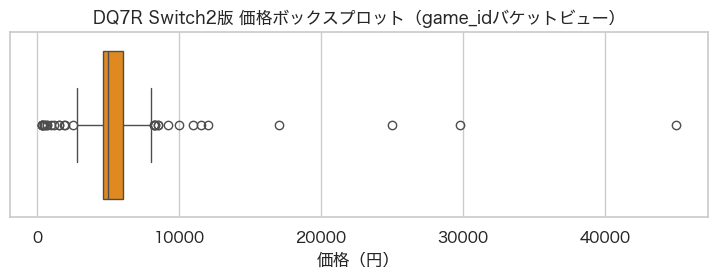

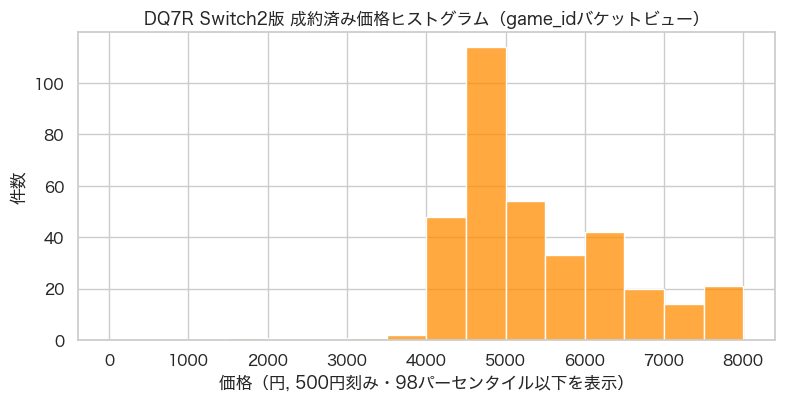

In [7]:
view_block(sw2_bucket, "Switch2", "game_idバケットビュー", "darkorange")

**game_id バケットビュー（`dq7r_reimagined_switch2` 全体）**：PS5 同様、`unknown`（Switch1 等）の混入を含み得ます。
価格分布の中心と、安値・高値のテールを確認します。

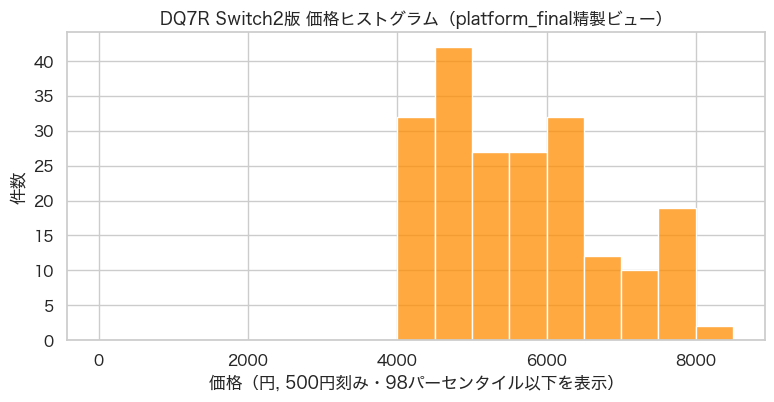

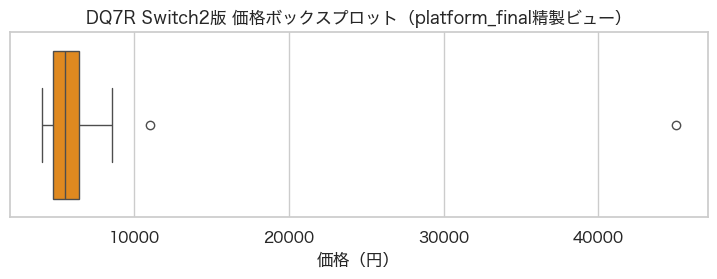

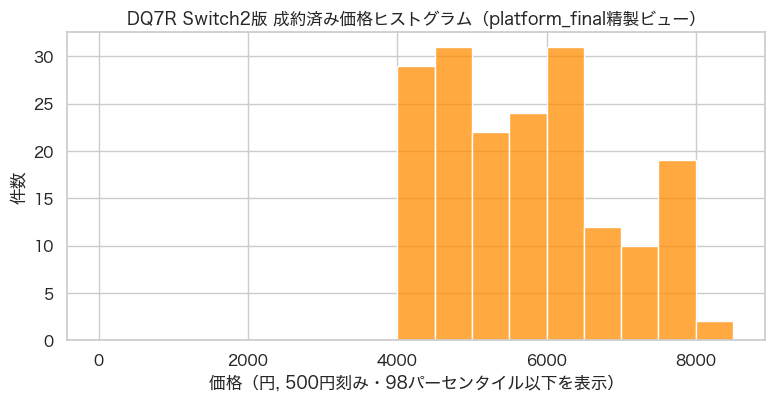

In [8]:
view_block(sw2_refined, "Switch2", "platform_final精製ビュー", "darkorange")

**platform_final 精製ビュー（`platform_final == 'Switch 2'`）**：Switch2 ソフトである確度の高い行に絞った分布です。
バケットビューとの差（混入の影響）と、中央値付近の価格帯を確認します。

## 5. game_id バケット vs platform_final 精製ビュー

同じプラットフォームでも「バケット（全体）」と「精製（platform_final 確定）」でサンプルがどう変わるか、
要約統計で並べて確認します。最後に PS5 と Switch2 の **精製ビュー同士** を比較します。

In [9]:
# PS5：View A（バケット全体） vs View B（platform_final=='PS5' 精製）
ps5_view_tbl = pd.DataFrame(
    [summarize(ps5_bucket), summarize(ps5_refined)],
    index=["View A: game_idバケット（全体）", "View B: platform_final=='PS5'（精製）"],
)
print("=== PS5：バケット vs 精製 ===")
ps5_view_tbl

=== PS5：バケット vs 精製 ===


,件数,成約率,価格中央値,平均価格,第1四分位,第3四分位
View A: game_idバケット（全体）,538.0,0.835,4700.0,4832.0,4100.0,5111.0
View B: platform_final=='PS5'（精製）,248.0,0.915,4200.0,4406.0,3700.0,4800.0


View A（全体）と View B（精製）で件数は減るものの、中央値・四分位がほぼ動かなければ、混入が相場感に与える影響は小さいと判断できます。

In [10]:
# Switch2：View A（バケット全体） vs View B（platform_final=='Switch 2' 精製）
sw2_view_tbl = pd.DataFrame(
    [summarize(sw2_bucket), summarize(sw2_refined)],
    index=["View A: game_idバケット（全体）", "View B: platform_final=='Switch 2'（精製）"],
)
print("=== Switch2：バケット vs 精製 ===")
sw2_view_tbl

=== Switch2：バケット vs 精製 ===


,件数,成約率,価格中央値,平均価格,第1四分位,第3四分位
View A: game_idバケット（全体）,448.0,0.797,5000.0,5497.0,4600.0,6000.0
View B: platform_final=='Switch 2'（精製）,206.0,0.883,5500.0,5874.0,4700.0,6397.5


Switch2 側も同様に、精製ビューに絞っても中央値水準が大きく動かないかを確認します。

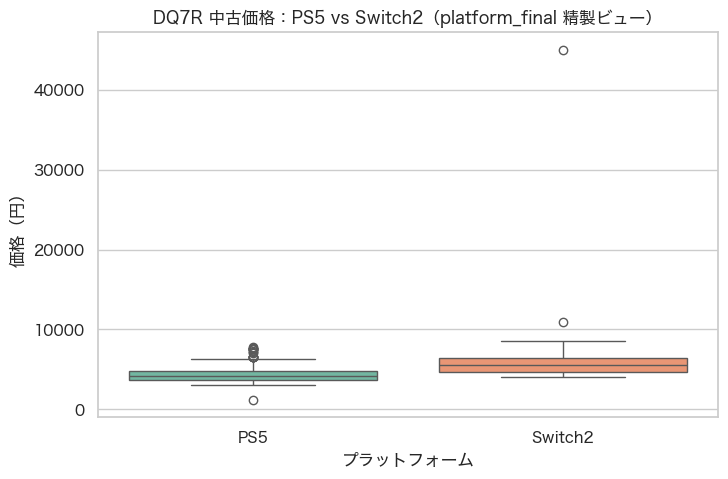

In [11]:
# PS5（精製） vs Switch2（精製）の比較
ref_ps5 = ps5_refined.copy(); ref_ps5["cmp"] = "PS5"
ref_sw2 = sw2_refined.copy(); ref_sw2["cmp"] = "Switch2"
df_cmp = pd.concat([ref_ps5, ref_sw2], ignore_index=True)

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df_cmp, x="cmp", y="price_jpy", hue="cmp",
            order=["PS5", "Switch2"], palette="Set2", legend=False, ax=ax)
ax.set_title("DQ7R 中古価格：PS5 vs Switch2（platform_final 精製ビュー）")
ax.set_xlabel("プラットフォーム")
ax.set_ylabel("価格（円）")
plt.show()

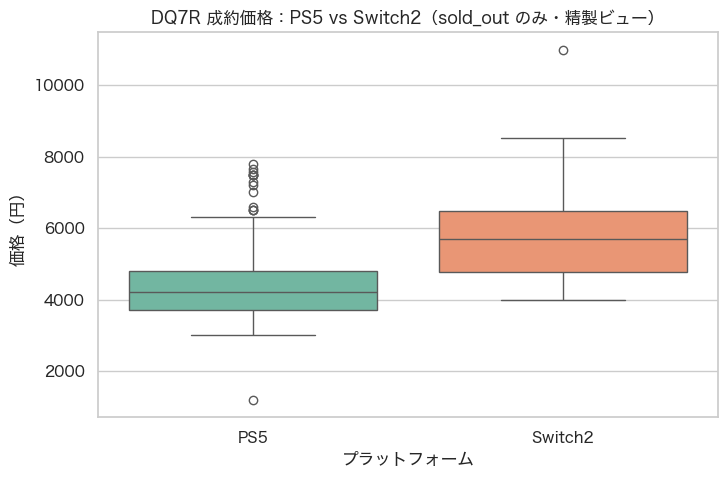

In [12]:
# 成約済み（sold_out）のみで同じ比較
sold_cmp = df_cmp[df_cmp.status_final == "sold_out"]
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=sold_cmp, x="cmp", y="price_jpy", hue="cmp",
            order=["PS5", "Switch2"], palette="Set2", legend=False, ax=ax)
ax.set_title("DQ7R 成約価格：PS5 vs Switch2（sold_out のみ・精製ビュー）")
ax.set_xlabel("プラットフォーム")
ax.set_ylabel("価格（円）")
plt.show()

In [13]:
# 精製ビュー同士の要約 + 中央値差
cmp_tbl = pd.DataFrame(
    [summarize(ref_ps5), summarize(ref_sw2)],
    index=["PS5（精製）", "Switch2（精製）"],
)
gap = ref_sw2["price_jpy"].median() - ref_ps5["price_jpy"].median()
print(f"中央値の差（Switch2 − PS5）: {gap:,.0f} 円")
cmp_tbl

中央値の差（Switch2 − PS5）: 1,300 円


,件数,成約率,価格中央値,平均価格,第1四分位,第3四分位
PS5（精製）,248.0,0.915,4200.0,4406.0,3700.0,4800.0
Switch2（精製）,206.0,0.883,5500.0,5874.0,4700.0,6397.5


上の表と図は **platform_final 精製ビュー同士** の比較です。中央値の差（Switch2 − PS5）が正なら
Switch2 版のほうが高値で取引されていることを示します。発売直後の新しいプラットフォーム向けは
供給がまだ薄く、相場が高めに出やすい傾向があります。一方で両プラットフォームとも成約率が高ければ、
価格差は「人気の差」というより **世代の新しさ・供給量の差** を反映していると読むのが自然です。

## 6. 外れ値とデータ上の注意点

In [14]:
# DQ7R 全体（3 game_id 合算）で価格の上位・下位を確認
df_all["title_short"] = df_all["title_raw"].apply(
    lambda s: textwrap.shorten(str(s), width=42, placeholder="…")
)
cols = ["game_id", "platform_final", "price_jpy", "condition_raw", "status_final", "title_short"]

print("=== 価格 上位10件（全クリーン行） ===")
display(df_all.nlargest(10, "price_jpy")[cols])
print("=== 価格 下位10件（全クリーン行） ===")
display(df_all.nsmallest(10, "price_jpy")[cols])

=== 価格 上位10件（全クリーン行） ===


,game_id,platform_final,price_jpy,condition_raw,status_final,title_short
900,dq7r_reimagined_switch,Switch 2,45000.0,新品、未使用,on_sale,Dragon Quest VII Reimagined Switch2
1530,dq7r_reimagined_switch2,Switch 2,45000.0,新品、未使用,on_sale,Dragon Quest VII Reimagined Switch2
366,dq7r_reimagined_ps5,unknown,30000.0,新品、未使用,on_sale,ドラゴンクエスト7 リメイク ボトルシップ
418,dq7r_reimagined_ps5,unknown,29800.0,新品、未使用,on_sale,ドラゴンクエスト7 Tシャツ アルス
903,dq7r_reimagined_switch,unknown,29800.0,新品、未使用,on_sale,ドラゴンクエスト7 Tシャツ アルス
1531,dq7r_reimagined_switch2,unknown,29800.0,新品、未使用,on_sale,ドラゴンクエスト7 Tシャツ アルス
756,dq7r_reimagined_switch,unknown,26100.0,新品、未使用,sold_out,T*d様 ドラゴンクエスト7 Reimagined ボトルシップ
415,dq7r_reimagined_ps5,unknown,25000.0,新品、未使用,on_sale,ドラゴンクエストVII Reimagined×G-SHOCK DW-5600
899,dq7r_reimagined_switch,unknown,25000.0,新品、未使用,on_sale,ドラゴンクエストVII Reimagined×G-SHOCK DW-5600
1529,dq7r_reimagined_switch2,unknown,25000.0,新品、未使用,on_sale,ドラゴンクエストVII Reimagined×G-SHOCK DW-5600


=== 価格 下位10件（全クリーン行） ===


,game_id,platform_final,price_jpy,condition_raw,status_final,title_short
422,dq7r_reimagined_ps5,unknown,300.0,新品、未使用,on_sale,ラバマスARTグミ ドラクエ7 ねこまどう
431,dq7r_reimagined_ps5,unknown,300.0,新品、未使用,on_sale,【新品】ドラゴンクエストVII リイマジンド ラバマスARTグミ スライム
908,dq7r_reimagined_switch,unknown,300.0,新品、未使用,on_sale,ラバマスARTグミ ドラクエ7 ねこまどう
916,dq7r_reimagined_switch,unknown,300.0,新品、未使用,on_sale,【新品】ドラゴンクエストVII リイマジンド ラバマスARTグミ スライム
1538,dq7r_reimagined_switch2,unknown,300.0,新品、未使用,on_sale,ラバマスARTグミ ドラクエ7 ねこまどう
1546,dq7r_reimagined_switch2,unknown,300.0,新品、未使用,on_sale,【新品】ドラゴンクエストVII リイマジンド ラバマスARTグミ スライム
429,dq7r_reimagined_ps5,unknown,333.0,新品、未使用,on_sale,ドラクエ7 ドラゴンクエスト7 ラバマスARTグミ エテポンゲ プチヒーロー
430,dq7r_reimagined_ps5,unknown,333.0,新品、未使用,on_sale,ドラゴンクエストVII リイマジンド ラバマスARTグミ ギガントドラゴン
915,dq7r_reimagined_switch,unknown,333.0,新品、未使用,on_sale,ドラクエ7 ドラゴンクエスト7 ラバマスARTグミ エテポンゲ プチヒーロー
917,dq7r_reimagined_switch,unknown,333.0,新品、未使用,on_sale,ドラゴンクエストVII リイマジンド ラバマスARTグミ ギガントドラゴン


上位・下位のテールには、本来の DQ7R 通常版ソフト以外が少数混じります。具体的には、

- **旧作 DQ7（`エデンの戦士たち`）**：PS / 3DS 版の旧ドラゴンクエストVII。新作 Reimagined とタイトルが近く、
  プラットフォーム未記載だと `unknown` として残ることがあります。
- **ガイドブック（`GUIDEBOOK` / 攻略本）** や、まれに **別ナンバリングの DQ**（例: VIII の 3DS 版）。
- 特典・バンドル・ケース単体などの **部分出品**。

これらは全クリーン行の **おおむね 1〜2% 程度** で、影響は主に価格の **テール（最高値・最安値）** に限られ、
**中央値・四分位はほとんど動きません**。そのため相場の中心を見るときは平均より **中央値** を主指標にするのが安全です。

将来的には除外キーワード（`エデンの戦士`, `GUIDEBOOK` など）を追加すればさらに削れますが、
**このノートはデータを一切変更しません**（読み取り専用）。

## 7. 簡単な考察とメモ

In [15]:
# 考察用の数値はすべてライブ集計（ハードコードなし）
def band(yen):
    # 中央値を「千円台」のざっくり表現にする
    return f"{yen/1000:.1f}千円"

ps5_med = ref_ps5["price_jpy"].median()
sw2_med = ref_sw2["price_jpy"].median()
gap = sw2_med - ps5_med
ps5_sold = (ps5_refined["status_final"] == "sold_out").mean()
sw2_sold = (sw2_refined["status_final"] == "sold_out").mean()

print("=== DQ7R 中古相場サマリ（platform_final 精製ビュー・ライブ集計） ===")
print(f"PS5     中央値: {ps5_med:,.0f} 円（約 {band(ps5_med)}）/ 成約率: {ps5_sold:.1%} / n={len(ps5_refined)}")
print(f"Switch2 中央値: {sw2_med:,.0f} 円（約 {band(sw2_med)}）/ 成約率: {sw2_sold:.1%} / n={len(sw2_refined)}")
print(f"中央値の差（Switch2 − PS5）: {gap:,.0f} 円")
print()
print(f"→ DQ7R の中古相場は、PS5 版が約 {band(ps5_med)}、Switch2 版が約 {band(sw2_med)} を中心に分布。")
print(f"  Switch2 版が中央値で約 {gap:,.0f} 円 高い水準。両版とも成約率が高く（{ps5_sold:.0%}/{sw2_sold:.0%}）、")
print("  発売直後の人気タイトルらしく『出せば売れる』動きになっています。")

=== DQ7R 中古相場サマリ（platform_final 精製ビュー・ライブ集計） ===
PS5     中央値: 4,200 円（約 4.2千円）/ 成約率: 91.5% / n=248
Switch2 中央値: 5,500 円（約 5.5千円）/ 成約率: 88.3% / n=206
中央値の差（Switch2 − PS5）: 1,300 円

→ DQ7R の中古相場は、PS5 版が約 4.2千円、Switch2 版が約 5.5千円 を中心に分布。
  Switch2 版が中央値で約 1,300 円 高い水準。両版とも成約率が高く（92%/88%）、
  発売直後の人気タイトルらしく『出せば売れる』動きになっています。


**まとめ（要点）**

- DQ7R PS5 版・Switch2 版とも中古相場の中心はおおむね数千円台で、上のセル出力のとおり Switch2 版が中央値で一段高い水準です。
- どちらも成約率が高く、発売直後で需要が供給を上回っている人気タイトルらしい挙動が見られます。
- 価格差は「人気差」よりも、世代の新しさ・供給量の差を反映していると解釈するのが妥当です。

**データ上の注意（再掲）**

- `platform_final` の `unknown` が多く、プラットフォーム確定行は全体の半分弱に留まります。
- 素の「Switch」（Switch1）は分類器が判別できず、`dq7r_reimagined_switch` のバケットは PS5/Switch/Switch2 が混在します。
  **分類器を変更しない限り、Switch1 単独の相場分析はできません。**
- 旧作 DQ7（エデンの戦士たち）やガイドブック等がごく一部混入していますが、影響はテールに限られます。

**次に分析したいこと**

- `unknown` 行の中身を手掛かりに、Switch1 / Switch2 の判別精度を上げられるか。
- FF7R・PRAGMATA との中古相場の比較（発売直後タイトル同士の価格・成約率の違い）。
- `days_since_release` / `scraped_at` を用いた時間軸での価格推移（再入荷・値下げイベント前後）。